## Lab 2: final challenges

__Вам предлагается решить задачу классификации сигналов или задачу классификации изображений. Или обе ;)__

__Выполнение этих заданий не является обязательным, но позитивно повлияет на вашу итоговую оценку. Успехов!__


### Part 4. HAR classification with raw data (2+ points)
__Disclaimer__: Это опциональная часть задания. Здесь придется экспериментировать, подбирать оптимальную структуру сети для решения задачи и активно искать подскзаки в сети.


Данное задание составлено на основе данного [поста](https://burakhimmetoglu.com/2017/08/22/time-series-classification-with-tensorflow/). С помощью вручную сгенерированных фичей и классических подходов задача распознования движений была решена с точностью 96%. 

Также будет полезным изучить [вот этот](https://github.com/healthDataScience/deep-learning-HAR), а так же [вот этот репозиторий](https://github.com/guillaume-chevalier/LSTM-Human-Activity-Recognition), где к данной задаче рассматривается несколько подходов.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import pylab
import warnings as w
import os

%matplotlib inline

In [2]:
import matplotlib
matplotlib.rcParams.update({'font.size':14})

Вернемся к задаче классификации движений на основе [данных](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones) из репозитория UCI ([прямая ссылка на скачивание](https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip)). 

В этот раз будем работать с исходными, а не предобработанными данными. Данные представляют собой сигналы с гироскопа и акселерометра, закрепленного на теле человека. Каждому семплу соотвествует 9 связанных временных рядов.

В начале приведена визуализация данных на основе PCA над вручную сгенерированными признаками. Для отрисовки графиков (цвет и легенда) нам также понадобятся метки классов.

In [3]:
#X_train_with_engineered_features = np.genfromtxt(os.path.join("UCI HAR Dataset", "train", "X_train.txt"))
#y_train = np.genfromtxt(os.path.join("UCI HAR Dataset", "train", "y_train.txt"))

#y_train_list = list(y_train)
#X_unique = np.array([X_train_with_engineered_features[y_train_list.index(l)]
#                             for l in sorted(list(set(y_train)))])

#legend_labels = ["WALKING", "WALKING.UP", "WALKING.DOWN", "SITTING", "STANDING", "LAYING"]
#colors_list = ['red', 'blue', 'green', 'orange', 'cyan', 'magenta']
#mapped_colors = [colors_list[int(i)-1] for i in y_train]

#from sklearn.decomposition import PCA
#pca = PCA()
#
#X_train_pca = pca.fit_transform(X_train_with_engineered_features)
#
#plt.figure(figsize=(15,10))
#pylab.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
#             c=mapped_colors)
#plt.grid()
#for idx, x in enumerate(pca.transform(X_unique)):
#    plt.scatter(x[0], 
#                x[1], 
#                c=colors_list[idx], 
#                label=legend_labels[idx])
#plt.xlabel('First principal component')
#plt.ylabel('Second principal component')
#plt.legend()

#### Предобработка данных
Предобработка сделана за нас автором [данного репозитория](https://github.com/guillaume-chevalier/LSTM-Human-Activity-Recognition). Будьте осторожны с путями.

In [4]:
# Useful Constants

# Those are separate normalised input features for the neural network
#INPUT_SIGNAL_TYPES = [
#    "body_acc_x_",
#    "body_acc_y_",
#    "body_acc_z_",
#    "body_gyro_x_",
#    "body_gyro_y_",
#    "body_gyro_z_",
#    "total_acc_x_",
#    "total_acc_y_",
#    "total_acc_z_"
#]

# Output classes to learn how to classify
#LABELS = [
#    "WALKING", 
#    "WALKING_UPSTAIRS", 
#    "WALKING_DOWNSTAIRS", 
#    "SITTING", 
#    "STANDING", 
#    "LAYING"
#]

#DATA_PATH = "./"

#DATASET_PATH = DATA_PATH + "UCI HAR Dataset/"
#print("\n" + "Dataset is now located at: " + DATASET_PATH)

#TRAIN = "train/"
#TEST = "test/"


# Load "X" (the neural network's training and testing inputs)

#def load_X(X_signals_paths):
#    X_signals = []
    
#    for signal_type_path in X_signals_paths:
#       file = open(signal_type_path, 'r')
        # Read dataset from disk, dealing with text files' syntax
#        X_signals.append(
#            [np.array(serie, dtype=np.float32) for serie in [
#                row.replace('  ', ' ').strip().split(' ') for row in file
#            ]]
#        )
#        file.close()
    
#    return np.transpose(np.array(X_signals), (1, 2, 0))

#X_train_signals_paths = [
#    os.path.join(*[DATASET_PATH, TRAIN, "Inertial Signals/", signal+"train.txt"]) for signal in INPUT_SIGNAL_TYPES
#]
#X_test_signals_paths = [
#    os.path.join(*[DATASET_PATH, TEST, "Inertial Signals/", signal+"test.txt"]) for signal in INPUT_SIGNAL_TYPES
#]

#X_train = load_X(X_train_signals_paths)
#X_test = load_X(X_test_signals_paths)


# Load "y" (the neural network's training and testing outputs)

#def load_y(y_path):
#    file = open(y_path, 'r')
    # Read dataset from disk, dealing with text file's syntax
#    y_ = np.array(
#        [elem for elem in [
#            row.replace('  ', ' ').strip().split(' ') for row in file
#        ]], 
#        dtype=np.int32
#    )
#    file.close()
    
    # Substract 1 to each output class for friendly 0-based indexing 
#    return y_ - 1

#y_train_path = os.path.join(DATASET_PATH, TRAIN, "y_train.txt")
#y_test_path = os.path.join(DATASET_PATH, TEST, "y_test.txt")

#y_train = load_y(y_train_path)
#y_test = load_y(y_test_path)

In [5]:
# Input Data 

#training_data_count = len(X_train)  # 7352 training series (with 50% overlap between each serie)
#test_data_count = len(X_test)  # 2947 testing series
#n_steps = len(X_train[0])  # 128 timesteps per series
#n_input = len(X_train[0][0])  # 9 input parameters per timestep


# LSTM Neural Network's internal structure

#n_hidden = 32 # Hidden layer num of features
#n_classes = 6 # Total classes (should go up, or should go down)


# Some debugging info

#print("Some useful info to get an insight on dataset's shape and normalisation:")
#print("(X shape, y shape, every X's mean, every X's standard deviation)")
#print(X_test.shape, y_test.shape, np.mean(X_test), np.std(X_test))
#print("The dataset is therefore properly normalised, as expected, but not yet one-hot encoded.")

#### Построение сети и эксперименты. (100% +)

__Ваша задача - построить сеть, которая решит задачу классификации с точностью (`accuracy`) не менее 86%.__
Разбалловка следующая:
* $=$86% - 2 points
* $>=$89% - 2.5 points
* $>=$91% - 3 points


__Warning!__ В сети существует несколько решений данной задачи с использованием различных фреймворков. При проверке это будет учитываться, так что свое решение нужно будет объяснить. Пожалуйста, не копируйте бездумно код, такие задания будут оценены 0 баллов. Если задача не решается - можете обратиться к заданию по классификации изображений.

После выполнения задания заполните небольшой отчет об экспериментах вида "Я пробовал(а) ... подходы и получил(а) ... результаты. Наконец, после N+1 чашки кофе/бессонной ночи у меня получилось, и весь секрет был в ..."

In [6]:
# Your experiments here

### Part 5. Dogs classification (2+ points)
__Disclaimer__: Это опциональная часть задания. Здесь придется экспериментировать, подбирать оптимальную структуру сети для решения задачи и активно искать подскзаки в сети.

Предлагаем вам решить задачу классификации пород собак. Вы можете обучить сеть с нуля или же воспользоваться методом fine-tuning'а. Полезная ссылка на [предобученные модели](https://pytorch.org/docs/stable/torchvision/models.html).

Данные можно скачать [отсюда](https://www.dropbox.com/s/vgqpz2f1lolxmlv/data.zip?dl=0). Датасет представлен 50 классами пород собак, которые можно найти в папке train в соответствующих директориях. При сдаче данной части задания вместе с ноутбуком необходимо отправить .csv-файл с предсказаниями классов тестовой выборки в формате: <имя изображения>,<метка класса> по одному объекту на строку. Ниже приведите код ваших экспериментов и короткий вывод по их результатам.

Будут оцениваться качество классификации (accuracy) на тестовой выборке (2 балла) и проведенные эксперименты (1 балл).
Разбалловка следующая:
* $>=$93% - 2 points
* $>=$84% - 1.5 points
* $>=$70% - 0.75 points

In [7]:
import os
import urllib.request
import zipfile
from pathlib import Path

target_dir = "/home/dima/Документы/ml/ML_algorithms/lab02_deep_learning"

#dl=1
url = "https://www.dropbox.com/scl/fi/v4mlweruozv8dbf4fx2xi/data.zip?rlkey=xke12fmqcui4malrwoqveqaai&e=1&dl=1"

#будет сохранён в target_dir
zip_name = "data.zip"
zip_path = os.path.join(target_dir, zip_name)

#целевая папка
Path(target_dir).mkdir(parents=True, exist_ok=True)

if not os.path.exists(zip_path):
    print("Скачивание датасета...")
    urllib.request.urlretrieve(url, zip_path)
    print("Скачивание завершено!")
else:
    print("Архив уже существует, пропускаем скачивание.")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(target_dir)
    print("Распаковка завершена!")

print(f"Данные готовы в {target_dir}")

Скачивание датасета...
Скачивание завершено!
Распаковка завершена!
Данные готовы в /home/dima/Документы/ml/ML_algorithms/lab02_deep_learning


In [8]:
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

data_dir = "/home/dima/Документы/ml/ML_algorithms/lab02_deep_learning/data/train"

train_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_full = datasets.ImageFolder(root=data_dir, transform=val_transform)

targets = train_full.targets

train_indices, val_indices = train_test_split(
    list(range(len(train_full))),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)  

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер валидационной выборки: {len(val_dataset)}")

Размер обучающей выборки: 5732
Размер валидационной выборки: 1434


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [9]:
data_root = "/home/dima/Документы/ml/ML_algorithms/lab02_deep_learning/data"
train_dir = os.path.join(data_root, "train")
test_dir = os.path.join(data_root, "test")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

batch_size = 32
num_workers = 4
num_classes = 50
num_epochs_phase1 = 8
num_epochs_phase2 = 12

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()
    return total_loss / len(loader), 100.0 * correct / total

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    return total_loss / len(loader), 100.0 * correct / total



Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


In [10]:
epoch_train_loss = []
epoch_train_acc  = []
epoch_val_loss   = []
epoch_val_acc    = []

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

best_val_acc = 0.0
for epoch in range(num_epochs_phase1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs_phase1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_phase1.pth')

    epoch_train_loss.append(train_loss)
    epoch_train_acc.append(train_acc)
    epoch_val_loss.append(val_loss)
    epoch_val_acc.append(val_acc)

Training:   0%|          | 0/180 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Validating: 100%|██████████| 45/45 [00:06<00:00,  6.66it/s]


Epoch 1/8: Train Loss=1.8878, Train Acc=55.69%, Val Acc=92.96%


Validating: 100%|██████████| 45/45 [00:06<00:00,  6.90it/s]


Epoch 2/8: Train Loss=0.9592, Train Acc=74.74%, Val Acc=93.86%


Validating: 100%|██████████| 45/45 [00:06<00:00,  6.96it/s]


...

Epoch 6/8: Train Loss=0.7326, Train Acc=79.05%, Val Acc=94.84%


Validating: 100%|██████████| 45/45 [00:06<00:00,  6.58it/s]


Epoch 7/8: Train Loss=0.7338, Train Acc=78.91%, Val Acc=94.98%


Validating: 100%|██████████| 45/45 [00:06<00:00,  6.55it/s]


Epoch 8/8: Train Loss=0.7282, Train Acc=79.22%, Val Acc=95.54%


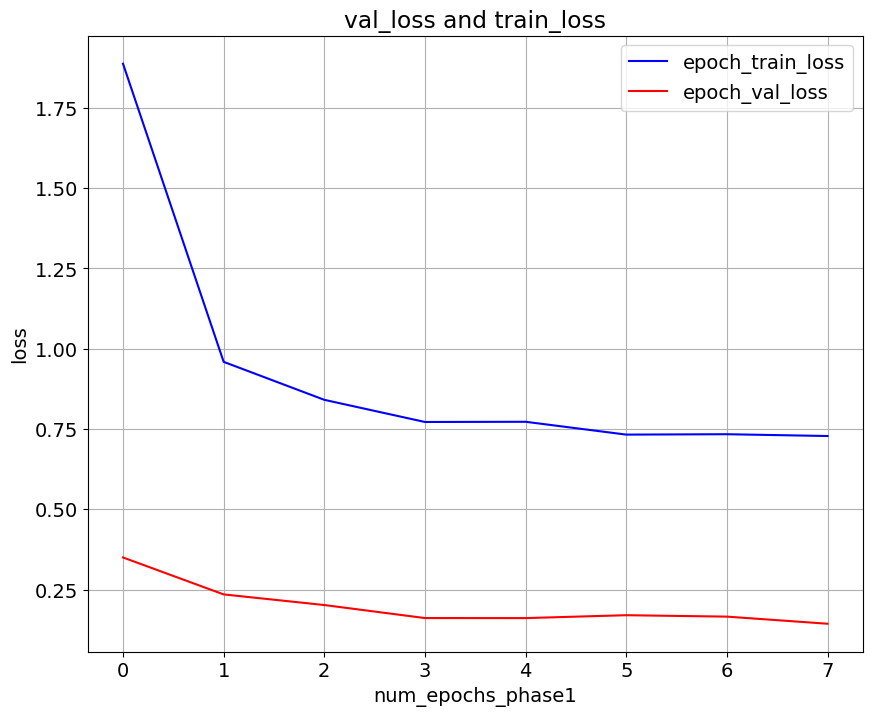

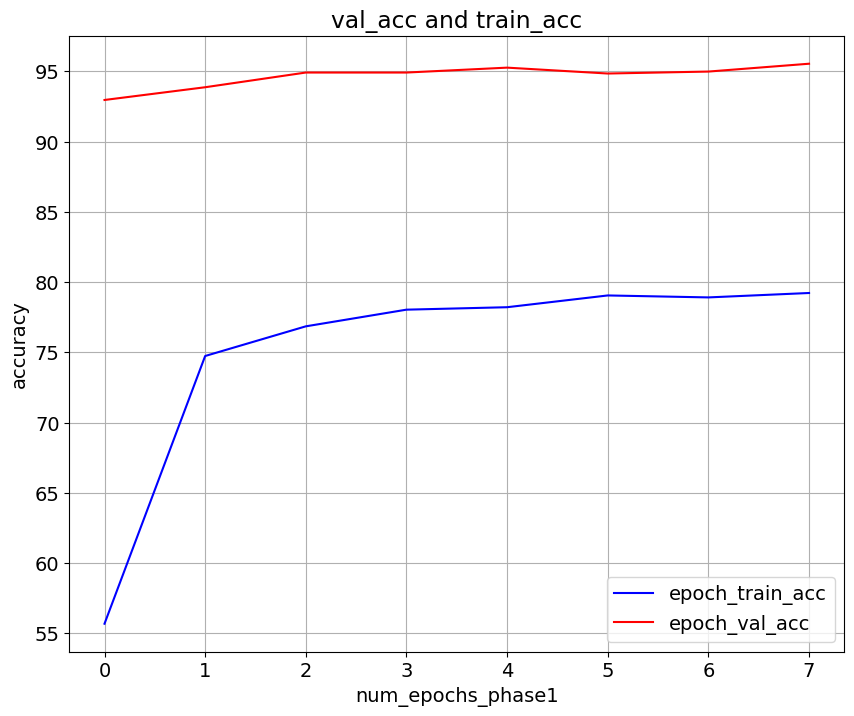

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.title(label="val_loss and train_loss")
plt.xlabel(xlabel="num_epochs_phase1")
plt.ylabel(ylabel="loss")
plt.grid()
plt.plot(np.arange(num_epochs_phase1), epoch_train_loss, label='epoch_train_loss', color='blue')
plt.plot(np.arange(num_epochs_phase1), epoch_val_loss, label='epoch_val_loss', color='red')
plt.legend()

plt.figure(figsize=(10,8))
plt.title(label="val_acc and train_acc")
plt.xlabel(xlabel="num_epochs_phase1")
plt.ylabel(ylabel="accuracy")
plt.grid()
plt.plot(np.arange(num_epochs_phase1), epoch_train_acc, label='epoch_train_acc', color='blue')
plt.plot(np.arange(num_epochs_phase1), epoch_val_acc, label='epoch_val_acc', color='red')
plt.legend()
plt.show()

In [12]:
epoch_train_loss2 = []
epoch_train_acc2  = []
epoch_val_loss2   = []
epoch_val_acc2    = []

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

best_val_acc = 0.0
for epoch in range(num_epochs_phase2):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{num_epochs_phase2}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_phase2.pth')

    epoch_train_loss2.append(train_loss)
    epoch_train_acc2.append(train_acc)
    epoch_val_loss2.append(val_loss)
    epoch_val_acc2.append(val_acc)

print(f"Best validation accuracy: {best_val_acc:.2f}%")

Validating: 100%|██████████| 45/45 [00:07<00:00,  5.91it/s]


Epoch 1/12: Train Loss=0.6668, Train Acc=81.09%, Val Acc=95.89%


Validating: 100%|██████████| 45/45 [00:07<00:00,  5.84it/s]


Epoch 2/12: Train Loss=0.5487, Train Acc=84.16%, Val Acc=96.44%


Validating: 100%|██████████| 45/45 [00:07<00:00,  5.84it/s]


...

Epoch 10/12: Train Loss=0.4378, Train Acc=87.30%, Val Acc=96.65%


Validating: 100%|██████████| 45/45 [00:07<00:00,  5.99it/s]


Epoch 11/12: Train Loss=0.4160, Train Acc=88.14%, Val Acc=97.00%


Validating: 100%|██████████| 45/45 [00:06<00:00,  6.78it/s]

Epoch 12/12: Train Loss=0.3909, Train Acc=88.76%, Val Acc=96.79%
Best validation accuracy: 97.00%


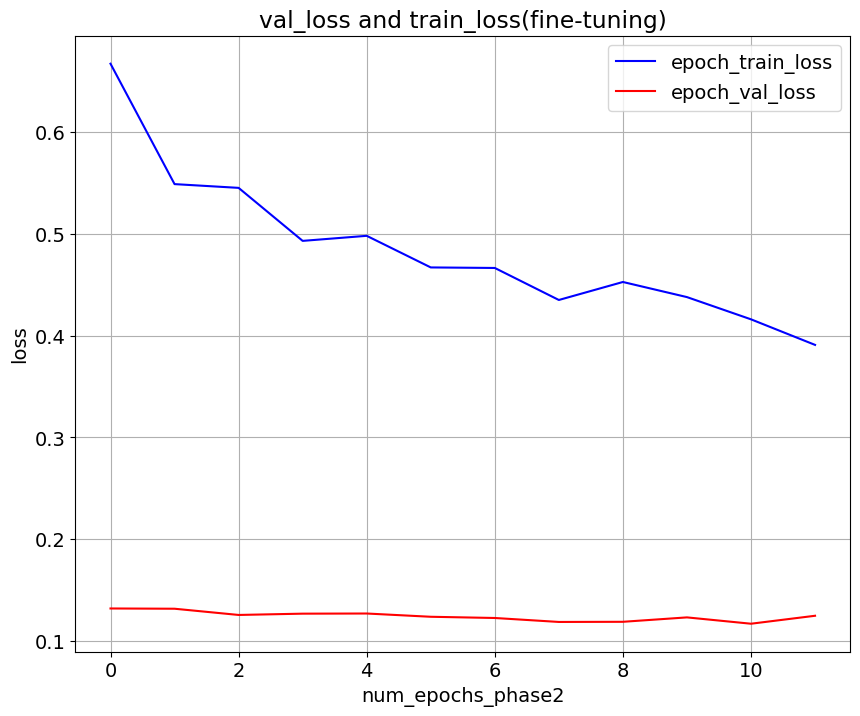

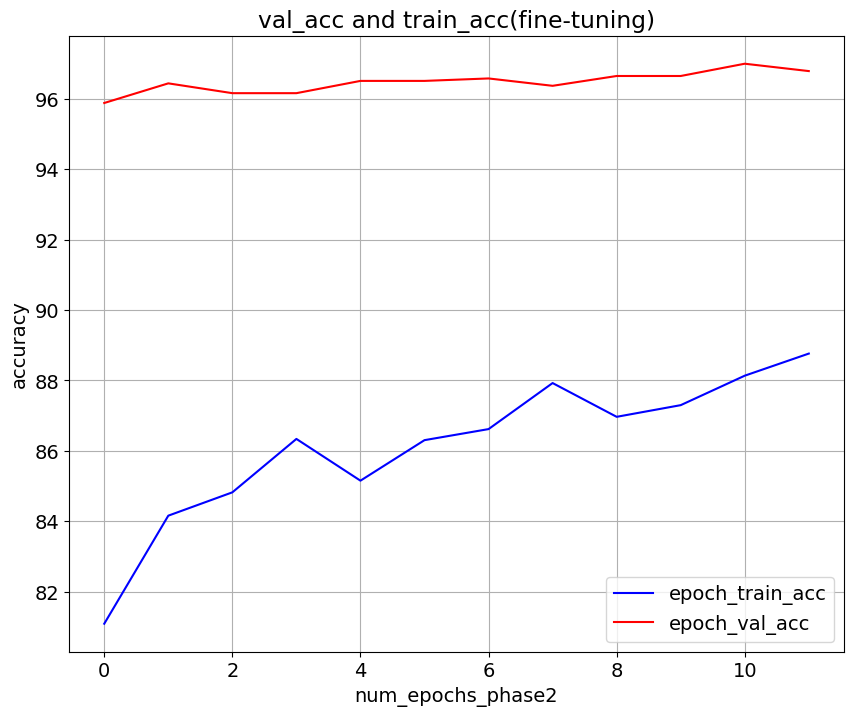

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.title(label="val_loss and train_loss(fine-tuning)")
plt.xlabel(xlabel="num_epochs_phase2")
plt.ylabel(ylabel="loss")
plt.grid()
plt.plot(np.arange(num_epochs_phase2), epoch_train_loss2, label='epoch_train_loss', color='blue')
plt.plot(np.arange(num_epochs_phase2), epoch_val_loss2, label='epoch_val_loss', color='red')
plt.legend()

plt.figure(figsize=(10,8))
plt.title(label="val_acc and train_acc(fine-tuning)")
plt.xlabel(xlabel="num_epochs_phase2")
plt.ylabel(ylabel="accuracy")
plt.grid()
plt.plot(np.arange(num_epochs_phase2), epoch_train_acc2, label='epoch_train_acc', color='blue')
plt.plot(np.arange(num_epochs_phase2), epoch_val_acc2, label='epoch_val_acc', color='red')
plt.legend()
plt.show()

In [14]:
model.load_state_dict(torch.load('best_model_phase2.pth'))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [15]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = datasets.folder.default_loader(img_path)
        if self.transform:
            image = self.transform(image)
        return image, img_name

test_dataset = TestDataset(test_dir, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

class_names = train_full.classes  # список пород в алфавитном порядке

predictions = []
with torch.no_grad():
    for images, img_names in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        for i, name in enumerate(img_names):
            predictions.append((name, class_names[preds[i].item()]))

# Сохраняем CSV
df = pd.DataFrame(predictions, columns=['image_name', 'label'])
df.to_csv('submission.csv', index=False)
print("Submission saved to submission.csv")

Testing: 100%|██████████| 47/47 [00:08<00:00,  5.80it/s]

Submission saved to submission.csv


In [18]:
from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/best_model_phase2.pth'
torch.save(model.state_dict(), save_path)
print(f'Модель сохранена: {save_path}')

load_path = '/content/drive/MyDrive/best_model_phase2.pth'
model.load_state_dict(torch.load(load_path, map_location=device))
model.eval()

Mounted at /content/drive
Модель сохранена: /content/drive/MyDrive/best_model_phase2.pth


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 